In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [18]:
df = pd.read_csv('/content/diabetes_prediction_dataset.csv.zip')

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [19]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [20]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


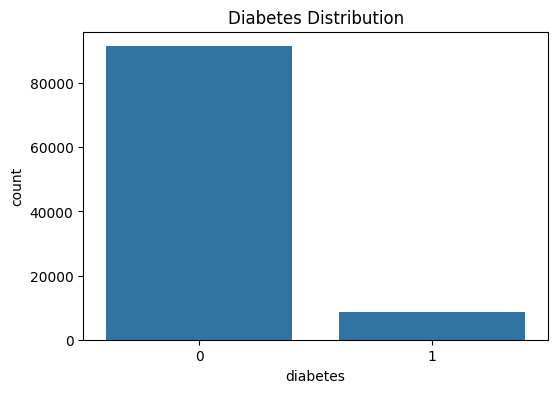

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Distribution")
plt.show()

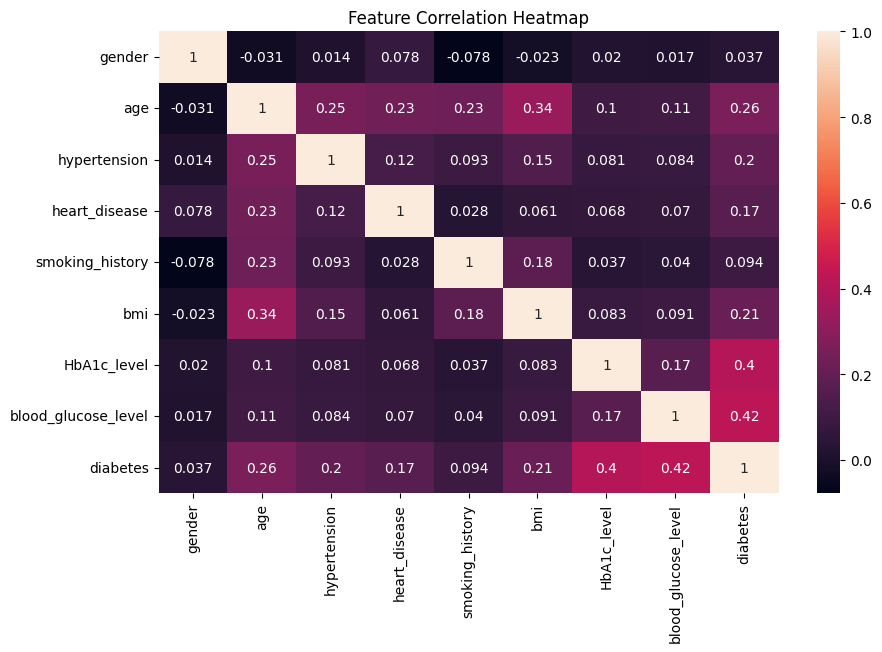

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)

plt.title("Feature Correlation Heatmap")
plt.show()

In [23]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print(X.head())
print(y.head())

   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0       0  80.0             0              1                4  25.19   
1       0  54.0             0              0                0  27.32   
2       1  28.0             0              0                4  27.32   
3       0  36.0             0              0                1  23.45   
4       1  76.0             1              1                1  20.14   

   HbA1c_level  blood_glucose_level  
0          6.6                  140  
1          6.6                   80  
2          5.7                  158  
3          5.0                  155  
4          4.8                  155  
0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80000, 8)
(20000, 8)


In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

accuracy_results = {}

In [26]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[name] = accuracy * 100

    print(f"{name} Accuracy: {accuracy*100:.2f}%")

Logistic Regression Accuracy: 95.86%
Decision Tree Accuracy: 95.32%
Random Forest Accuracy: 97.00%


In [27]:
best_model = RandomForestClassifier(n_estimators=100)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.94      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



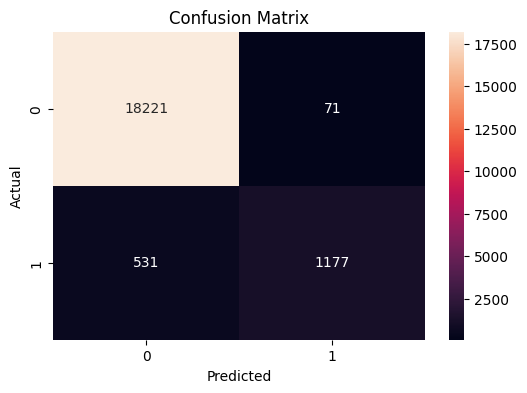

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

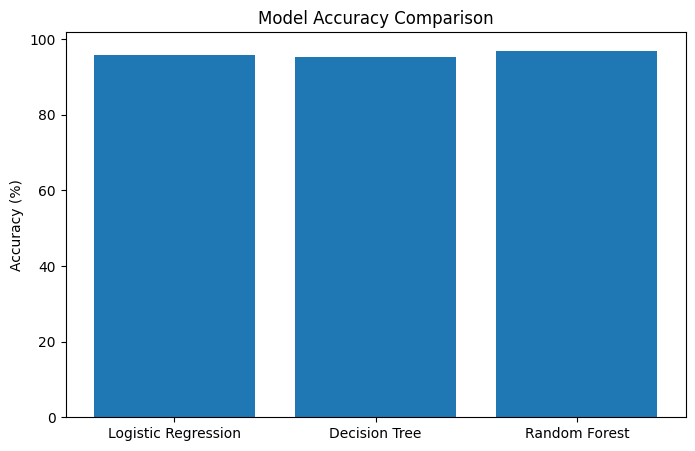

In [30]:
model_names = list(accuracy_results.keys())
accuracy_values = list(accuracy_results.values())

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracy_values)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

In [31]:
print("Enter Patient Details")

gender = int(input("Gender (0 = Female, 1 = Male): "))
age = float(input("Age: "))
hypertension = int(input("Hypertension (0 = No, 1 = Yes): "))
heart_disease = int(input("Heart Disease (0 = No, 1 = Yes): "))
smoking_history = int(input("Smoking History Number: "))
bmi = float(input("BMI: "))
HbA1c_level = float(input("HbA1c Level: "))
blood_glucose_level = float(input("Blood Glucose Level: "))

Enter Patient Details
Gender (0 = Female, 1 = Male): 1
Age: 9
Hypertension (0 = No, 1 = Yes): 0
Heart Disease (0 = No, 1 = Yes): 0
Smoking History Number: 0
BMI: 55.5
HbA1c Level: 45.5
Blood Glucose Level: 95.5


In [32]:
input_data = pd.DataFrame([[
    gender,
    age,
    hypertension,
    heart_disease,
    smoking_history,
    bmi,
    HbA1c_level,
    blood_glucose_level
]], columns=X.columns)

prediction = best_model.predict(input_data)

if prediction[0] == 1:
    print(" High Chance of Diabetes")
    print("\nSuggestions:")
    print("- Reduce sugar intake")
    print("- Exercise regularly")
    print("- Consult doctor")
else:
    print(" Low Risk of Diabetes")
    print("\nSuggestions:")
    print("- Maintain healthy lifestyle")

 High Chance of Diabetes

Suggestions:
- Reduce sugar intake
- Exercise regularly
- Consult doctor
